In [9]:
# Cell 1: Install dependencies
!pip install ultralytics albumentations -q

# Imports
from ultralytics import YOLO
import yaml
import os
print("✅ All imports successful!")

✅ All imports successful!


In [12]:
# Cell 2: Set dataset path
DATASET_PATH = '/kaggle/input/datasets/noumanzahid85/exdark-yolo/ExDark'

# Verify structure
print("Checking dataset structure...")
print("Contents:", os.listdir(DATASET_PATH))
print("\nImages folder:", os.listdir(os.path.join(DATASET_PATH, 'images')))
print("Labels folder:", os.listdir(os.path.join(DATASET_PATH, 'labels')))

Checking dataset structure...
Contents: ['labels', 'images']

Images folder: ['val', 'test', 'train']
Labels folder: ['all', 'val', 'test', 'train']


In [14]:
# Cell 3: Create dataset YAML
yaml_content = {
    'path': DATASET_PATH,
    'train': 'images/train',     # relative to path
    'val': 'images/val',         # relative to path
    'test': 'images/test',       # relative to path
    'nc': 12,                    # number of classes
    'names': ['Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat',
              'Chair', 'Cup', 'Dog', 'Motorbike', 'People', 'Table']
}

with open('exdark.yaml', 'w') as f:
    yaml.dump(yaml_content, f)

print("✅ YAML file created successfully!")
print(f"Train path: {os.path.join(DATASET_PATH, 'images/train')}")
print(f"Exists: {os.path.exists(os.path.join(DATASET_PATH, 'images/train'))}")

✅ YAML file created successfully!
Train path: /kaggle/input/datasets/noumanzahid85/exdark-yolo/ExDark/images/train
Exists: True


In [15]:
# Cell 4: Fine-tune YOLOv8 on ExDark dataset
model = YOLO('yolov8n.pt')  # Start from COCO pretrained weights

results = model.train(
    data='exdark.yaml',
    epochs=30,               # 30 epochs for fine-tuning
    imgsz=640,               # image size
    batch=16,                # batch size (fits in T4 GPU)
    lr0=0.001,               # initial learning rate
    lrf=0.01,                # final learning rate factor
    momentum=0.937,          # SGD momentum
    weight_decay=0.0005,     # weight decay
    warmup_epochs=3,         # warmup epochs
    patience=10,             # early stopping patience
    device=0,                # GPU device (0 = first GPU)
    project='exdark_run',    # project name
    name='yolov8n_exdark',   # run name
    pretrained=True,         # keep pretrained backbone
    verbose=True,            # print detailed logs
)

print("✅ Training completed!")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=exdark.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_exdark-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspecti

In [20]:
# ── Cell 6: Download best.pt (Final Working Version)
from IPython.display import FileLink, display
import os
import shutil

# Your actual model path from training
best_model_path = '/kaggle/working/runs/detect/exdark_run/yolov8n_exdark-2/weights/best.pt'

if os.path.exists(best_model_path):
    # Copy to root for easy download
    shutil.copy(best_model_path, 'best.pt')
    os.makedirs('models', exist_ok=True)
    shutil.copy(best_model_path, 'models/best.pt')
    
    print(f" Model found!")
    print(f" Size: {os.path.getsize('best.pt') / 1024 / 1024:.2f} MB")
    print(f"\n Click to download:")
    display(FileLink('best.pt'))
    print(f"\n Also saved to: models/best.pt")
else:
    print(f" Model not found at: {best_model_path}")
    
    # Search everywhere
    print("\n Searching for best.pt...")
    found = False
    for root, dirs, files in os.walk('/kaggle/working'):
        if 'best.pt' in files:
            full_path = os.path.join(root, 'best.pt')
            print(f"FOUND at: {full_path}")
            shutil.copy(full_path, 'best.pt')
            os.makedirs('models', exist_ok=True)
            shutil.copy(full_path, 'models/best.pt')
            display(FileLink('best.pt'))
            found = True
            break
    
    if not found:
        print(" No best.pt found. Training may have failed.")

 Model found!
 Size: 5.94 MB

 Click to download:


/kaggle/working/best.pt


 Also saved to: models/best.pt


Testing: 2015_00765.jpg

image 1/1 /kaggle/input/datasets/noumanzahid85/exdark-yolo/ExDark/images/test/2015_00765.jpg: 416x640 1 Boat, 43.3ms
Speed: 2.1ms preprocess, 43.3ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)


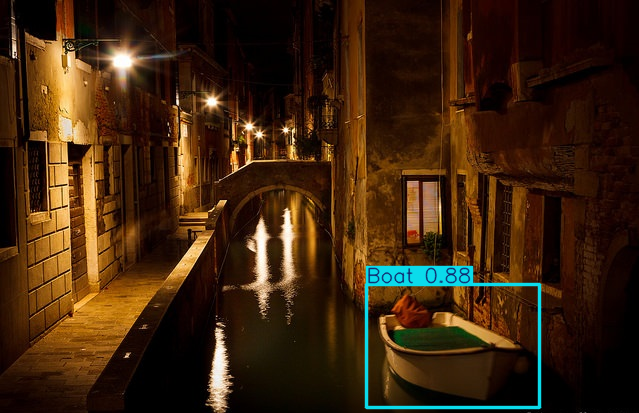

✅ Detected 1 objects


In [29]:
# ── Cell 7: Test model with correct path
from ultralytics import YOLO
import os

model = YOLO('best.pt')

# Correct path
test_dir = '/kaggle/input/datasets/noumanzahid85/exdark-yolo/ExDark/images/test'

if os.path.exists(test_dir):
    images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]
    if images:
        img_path = os.path.join(test_dir, images[10])
        print(f"Testing: {images[10]}")
        results = model(img_path)
        results[0].show()
        print(f"✅ Detected {len(results[0].boxes)} objects")
    else:
        print("No images in test folder")
else:
    print(f"Path not found: {test_dir}")
    # Show what exists
    print("\nActual structure:")
    os.system('ls -la /kaggle/input/datasets/noumanzahid85/exdark-yolo/ExDark/images/')